
# Notebook 02 — Data Cleaning & Feature Organization

**Purpose:** turn the raw Amazon ML Challenge data into a clean, model-ready dataset.

This notebook is deliberately focused on **data quality**, not model training.

### What it handles
- Schema and dtype validation
- Duplicate rows / duplicate product IDs
- Missing and blank text
- Invalid numeric values (`NaN`, `inf`, `-inf`)
- Invalid target values (`<= 0`)
- Extreme target outliers using a **log-space robust rule**
- Text normalization while preserving useful NLP information
- Dimension extraction from `TITLE + BULLET_POINTS + DESCRIPTION`
- `L`, `W`, `H`, `L×W`, `L×W×H` parsing
- Unit normalization to a single unit
- Product-type-aware median imputation for dimension features
- Train/test overlap and leakage checks
- Clean train/test export
- Cleaning audit so every removed row is traceable

> **Important:** We never use the test target because it does not exist. All learned cleaning parameters are fitted from training data only.


## 0. Configuration

In [3]:

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

print("Libraries loaded.")


Libraries loaded.


In [4]:

# ============================================================
# CONFIGURATION
# ============================================================
DATA_MODE = "debug"   # "debug" | "experiment" | "full"

DATA_PATHS = {
    "debug": "../dataset/sampled/debug",
    "experiment": "../dataset/sampled/experiment",
    "full": "../dataset"
}

DATA_DIR = DATA_PATHS[DATA_MODE]

OUTPUT_DIR = "../dataset/cleaned"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(DATA_DIR, "train.csv")
TEST_FILE  = os.path.join(DATA_DIR, "test.csv")

CLEAN_TRAIN_FILE = os.path.join(OUTPUT_DIR, f"train_clean_{DATA_MODE}.csv")
CLEAN_TEST_FILE  = os.path.join(OUTPUT_DIR, f"test_clean_{DATA_MODE}.csv")
AUDIT_FILE       = os.path.join(OUTPUT_DIR, f"cleaning_audit_{DATA_MODE}.csv")
RULES_FILE       = os.path.join(OUTPUT_DIR, f"cleaning_rules_{DATA_MODE}.json")

# Target outlier policy
REMOVE_EXTREME_TARGET_OUTLIERS = True

# Robust log-space threshold:
# log1p(target) > Q3 + multiplier * IQR
TARGET_IQR_MULTIPLIER = 3.0

# Additional absolute safety limit. Set to None to disable.
# This is NOT the primary outlier rule.
ABSOLUTE_TARGET_MAX = None

# Dimension sanity limit after unit normalization.
# Values above this are treated as suspicious parsed measurements.
MAX_DIMENSION_CM = 100000.0

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_DIR: ../dataset/sampled/debug
OUTPUT_DIR: ../dataset/cleaned


## 1. Imports

## 2. Load raw data

In [5]:

df_train_raw = pd.read_csv(TRAIN_FILE)
df_test_raw = pd.read_csv(TEST_FILE)

print(f"Raw train: {df_train_raw.shape}")
print(f"Raw test : {df_test_raw.shape}")

display(df_train_raw.head(3))


Raw train: (50000, 6)
Raw test : (10000, 5)


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
0,2028640,WHICHWOOD Wooden Handmade Ashok Stamb with Clock and Flag Desk Organizer for Office and Home Decoration (Brown),Purely high material |Ashok Stambh will definitely going to amuse your guests and visitors and will give royal touch...,"Wooden Ashoka pillar- National Emblem-Ashoka Stambh. Size: Height: 8"" Hand carved & Best quality wood used. Proper c...",8271,300.0
1,1369397,"Red and Black Throw Pillow Cushion Cover by Ambesonne, Poppy Field Spring Time Flower Grass Open Sky Photo, Decorati...","[18 INCHES x 18 INCHES - DOUBLE SIDED PRINT - With Zipper. Cut and sewn by hand. INSERT NOT INCLUDED,MADE FROM - 100...",Makeover and refresh your rooms with just a single touch! Start with these fun and decorative cushion cases. These u...,10324,1080.0
2,462899,Lives that Made Greek History,NaN,NaN,12482,550.0


## 3. Schema validation

In [6]:

REQUIRED_TRAIN = [
    "PRODUCT_ID", "TITLE", "BULLET_POINTS",
    "DESCRIPTION", "PRODUCT_TYPE_ID", "PRODUCT_LENGTH"
]

REQUIRED_TEST = [
    "PRODUCT_ID", "TITLE", "BULLET_POINTS",
    "DESCRIPTION", "PRODUCT_TYPE_ID"
]

missing_train = [c for c in REQUIRED_TRAIN if c not in df_train_raw.columns]
missing_test  = [c for c in REQUIRED_TEST if c not in df_test_raw.columns]

assert not missing_train, f"Missing train columns: {missing_train}"
assert not missing_test, f"Missing test columns: {missing_test}"
assert "PRODUCT_LENGTH" not in df_test_raw.columns, "Target leakage: PRODUCT_LENGTH exists in test."

print("Schema validation passed.")
print("\nTrain dtypes:")
display(df_train_raw.dtypes.to_frame("dtype"))


Schema validation passed.

Train dtypes:


,dtype
PRODUCT_ID,int64
TITLE,str
BULLET_POINTS,str
DESCRIPTION,str
PRODUCT_TYPE_ID,int64
PRODUCT_LENGTH,float64


## 4. Standardize column types

In [7]:

TEXT_COLS = ["TITLE", "BULLET_POINTS", "DESCRIPTION"]

def standardize_types(df, is_train=True):
    df = df.copy()

    # IDs are kept as strings to prevent accidental numeric interpretation.
    df["PRODUCT_ID"] = df["PRODUCT_ID"].astype("string")
    df["PRODUCT_TYPE_ID"] = pd.to_numeric(
        df["PRODUCT_TYPE_ID"], errors="coerce"
    )

    for col in TEXT_COLS:
        df[col] = df[col].fillna("").astype("string")

    if is_train:
        df["PRODUCT_LENGTH"] = pd.to_numeric(
            df["PRODUCT_LENGTH"], errors="coerce"
        )

    return df

train = standardize_types(df_train_raw, True)
test = standardize_types(df_test_raw, False)

print(train.dtypes)


PRODUCT_ID          string
TITLE               string
BULLET_POINTS       string
DESCRIPTION         string
PRODUCT_TYPE_ID      int64
PRODUCT_LENGTH     float64
dtype: object


## 5. Cleaning audit framework

In [8]:

# Every removed training row receives a reason.
# This makes the cleaning process reproducible and explainable.

audit = pd.DataFrame({
    "PRODUCT_ID": train["PRODUCT_ID"].astype("string"),
    "removed": False,
    "reason": ""
}, index=train.index)

def mark_removed(mask, reason):
    mask = pd.Series(mask, index=train.index).fillna(False)
    audit.loc[mask, "removed"] = True

    empty_reason = audit.loc[mask, "reason"].eq("")
    audit.loc[mask[mask].index[empty_reason], "reason"] = reason

print("Audit framework ready.")


Audit framework ready.


## 6. Remove exact duplicate rows and duplicate PRODUCT_IDs

In [9]:

# Exact duplicate rows
exact_dup = train.duplicated(keep="first")
mark_removed(exact_dup, "exact_duplicate_row")

# Duplicate PRODUCT_IDs:
# keep the first occurrence and remove later copies.
dup_product_id = train["PRODUCT_ID"].duplicated(keep="first")
mark_removed(dup_product_id, "duplicate_product_id")

# Do the same for test, but retain the first occurrence.
test_exact_dup = test.duplicated(keep="first")
test_dup_product_id = test["PRODUCT_ID"].duplicated(keep="first")

test = test.loc[~test_exact_dup & ~test_dup_product_id].copy()

print("Train exact duplicates:", exact_dup.sum())
print("Train duplicate PRODUCT_IDs:", dup_product_id.sum())
print("Test rows removed for duplication:", (test_exact_dup | test_dup_product_id).sum())


Train exact duplicates: 0
Train duplicate PRODUCT_IDs: 0
Test rows removed for duplication: 0


## 7. Remove invalid target rows

In [10]:

target = train["PRODUCT_LENGTH"]

invalid_nan = target.isna()
invalid_inf = ~np.isfinite(target.fillna(np.nan))
invalid_nonpositive = target.notna() & (target <= 0)

mark_removed(invalid_nan, "target_missing")
mark_removed(invalid_inf, "target_non_finite")
mark_removed(invalid_nonpositive, "target_non_positive")

print("Missing target       :", invalid_nan.sum())
print("Non-finite target    :", invalid_inf.sum())
print("Non-positive target  :", invalid_nonpositive.sum())


Missing target       : 0
Non-finite target    : 0
Non-positive target  : 0



## 8. Extreme target outlier detection

The target is strongly right-skewed, so a raw-space IQR rule is not appropriate.

We use:

`log1p(PRODUCT_LENGTH)`

and detect extreme values above:

`Q3 + 3 × IQR`

This is a **robust anomaly filter**, not an arbitrary `20,000` cutoff.

The threshold is learned from the valid training target only.


In [11]:

valid_target = target[
    target.notna() &
    np.isfinite(target) &
    (target > 0)
].astype(float)

log_target = np.log1p(valid_target)

q1_log = log_target.quantile(0.25)
q3_log = log_target.quantile(0.75)
iqr_log = q3_log - q1_log

log_upper = q3_log + TARGET_IQR_MULTIPLIER * iqr_log
robust_target_upper = float(np.expm1(log_upper))

if ABSOLUTE_TARGET_MAX is not None:
    final_target_upper = min(robust_target_upper, ABSOLUTE_TARGET_MAX)
else:
    final_target_upper = robust_target_upper

extreme_target = (
    train["PRODUCT_LENGTH"].notna()
    & np.isfinite(train["PRODUCT_LENGTH"])
    & (train["PRODUCT_LENGTH"] > final_target_upper)
)

if REMOVE_EXTREME_TARGET_OUTLIERS:
    mark_removed(extreme_target, "extreme_target_outlier")

print(f"log-space Q1       : {q1_log:.4f}")
print(f"log-space Q3       : {q3_log:.4f}")
print(f"log-space IQR      : {iqr_log:.4f}")
print(f"Robust upper bound : {robust_target_upper:,.4f}")
print(f"Final upper bound  : {final_target_upper:,.4f}")
print(f"Extreme rows       : {extreme_target.sum():,}")


log-space Q1       : 6.2399
log-space Q3       : 6.9881
log-space IQR      : 0.7482
Robust upper bound : 10,225.4326
Final upper bound  : 10,225.4326
Extreme rows       : 438


## 9. Inspect the rows that will be removed

In [12]:

removed_target_rows = train.loc[
    audit["reason"].isin([
        "target_missing",
        "target_non_finite",
        "target_non_positive",
        "extreme_target_outlier"
    ]),
    ["PRODUCT_ID", "TITLE", "PRODUCT_TYPE_ID", "PRODUCT_LENGTH"]
].copy()

print(f"Rows flagged by target cleaning: {len(removed_target_rows):,}")
display(removed_target_rows.sort_values("PRODUCT_LENGTH", ascending=False).head(50))


Rows flagged by target cleaning: 438


,PRODUCT_ID,TITLE,PRODUCT_TYPE_ID,PRODUCT_LENGTH
1625,2263460,TOPBATHY 1 Set Ladle Colander Spoon Stainless Steel Long Handle Soup Oil Separator Scoop Oil Filter Skimmer Spoon So...,11601,1.774080e+08
28060,1275322,Speedo Speedo Youth Big Boys' Rapid Splice Jammer Shorts Swimsuit,2275,9.769000e+06
45522,1562622,Dotti Ibiza Stripe Side Shirred Hoodie Tunic Cover-Up Black/White XL,3072,9.398900e+06
8127,1404278,Spellbound Deep Plunge One Piece Swimsuit,3073,8.542000e+06
25097,791220,Speedo Sprint Swim Goggles (Black/Clear),4625,4.935900e+06
15412,1596312,"E-Retailer® PVC Waterproof Anti-Skid Multipurpose Shelf Linen Sheet for Kitchen Shelves, Drawer & Fridge (Color-Stri...",1346,7.716520e+05
12793,2819354,Playbuys Trendy Popular Mini-Size Wishing Bottle Necklace Pendant 10 Pcs Transparent,1704,7.087008e+05
8073,2948745,TINY STORE Leaf Men Women Vintage Pendant Adjustable Leather Cord Necklace Chain Brown,3365,6.349606e+05
48240,2839289,Loom Tree Two-strand Wheat Chain Bracelet Man Wrist Hand Bracelet 02 Gold,12440,5.461811e+05
44780,2127196,"90 Degree Imported Nylon Monofilament Super Strong Fishing Line Reel with Extra Flexibility, 100 m (0.80 mm, Clear W...",4315,3.937000e+05


## 10. Apply training-row removal

In [14]:

train_clean = train.loc[~audit["removed"]].copy()

print(f"Train before cleaning: {len(train):,}")
print(f"Train after cleaning : {len(train_clean):,}")
print(f"Rows removed         : {len(train) - len(train_clean):,}")
print(f"Removal percentage   : {(len(train)-len(train_clean))/len(train)*100:.4f}%")

assert len(train_clean) > 0
assert train_clean["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train_clean["PRODUCT_LENGTH"]).all()
assert (train_clean["PRODUCT_LENGTH"] > 0).all()


Train before cleaning: 50,000
Train after cleaning : 49,562
Rows removed         : 438
Removal percentage   : 0.8760%


## 11. Normalize text fields

In [15]:

# Preserve case because later TF-IDF can decide how to handle it.
# We only remove formatting noise here.

ZERO_WIDTH_RE = re.compile(r"[\u200B-\u200D\uFEFF]")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text_series(s):
    s = s.fillna("").astype("string")
    s = s.str.replace(ZERO_WIDTH_RE, "", regex=True)
    s = s.str.replace("\r", " ", regex=False)
    s = s.str.replace("\n", " ", regex=False)
    s = s.str.replace(MULTISPACE_RE, " ", regex=True)
    s = s.str.strip()
    return s

for col in TEXT_COLS:
    train_clean[col] = clean_text_series(train_clean[col])
    test[col] = clean_text_series(test[col])

print("Text normalization completed.")


Text normalization completed.


## 12. Remove obviously broken PRODUCT_ID / PRODUCT_TYPE_ID records

In [16]:

# Product IDs should exist and should not be blank.
bad_train_id = (
    train_clean["PRODUCT_ID"].isna()
    | train_clean["PRODUCT_ID"].str.strip().eq("")
)

bad_test_id = (
    test["PRODUCT_ID"].isna()
    | test["PRODUCT_ID"].str.strip().eq("")
)

print("Bad train PRODUCT_ID:", bad_train_id.sum())
print("Bad test PRODUCT_ID :", bad_test_id.sum())

train_clean = train_clean.loc[~bad_train_id].copy()
test = test.loc[~bad_test_id].copy()

# PRODUCT_TYPE_ID is categorical. Missing values are retained as a dedicated
# unknown category rather than dropping potentially useful products.
train_clean["PRODUCT_TYPE_ID"] = train_clean["PRODUCT_TYPE_ID"].fillna(-1).astype("int64")
test["PRODUCT_TYPE_ID"] = test["PRODUCT_TYPE_ID"].fillna(-1).astype("int64")


Bad train PRODUCT_ID: 0
Bad test PRODUCT_ID : 0


## 13. Build combined product text for dimension extraction

In [17]:

def combined_text(df):
    return (
        df["TITLE"].fillna("").astype("string") + " " +
        df["BULLET_POINTS"].fillna("").astype("string") + " " +
        df["DESCRIPTION"].fillna("").astype("string")
    ).str.replace(r"\s+", " ", regex=True).str.strip()

train_clean["__TEXT_ALL"] = combined_text(train_clean)
test["__TEXT_ALL"] = combined_text(test)

display(train_clean[["TITLE", "__TEXT_ALL"]].head(3))


,TITLE,__TEXT_ALL
0,WHICHWOOD Wooden Handmade Ashok Stamb with Clock and Flag Desk Organizer for Office and Home Decoration (Brown),WHICHWOOD Wooden Handmade Ashok Stamb with Clock and Flag Desk Organizer for Office and Home Decoration (Brown) Pure...
1,"Red and Black Throw Pillow Cushion Cover by Ambesonne, Poppy Field Spring Time Flower Grass Open Sky Photo, Decorati...","Red and Black Throw Pillow Cushion Cover by Ambesonne, Poppy Field Spring Time Flower Grass Open Sky Photo, Decorati..."
2,Lives that Made Greek History,Lives that Made Greek History



## 14. Dimension parser

Supported forms include:

- `12 x 10`
- `12 × 10`
- `12 X 10 X 5`
- `12in x 10in`
- `30 cm x 20 cm`
- `1.5 m x 2 m`

We extract up to three dimensions and normalize them to **centimetres**.

The parser intentionally does not guess dimensions from unrelated numbers.


In [18]:

NUMBER = r"(\d+(?:\.\d+)?)"
UNIT = r"(mm|millimeters?|cm|centimeters?|m|meters?|in|inch(?:es)?|ft|feet|foot)"
SEP = r"(?:x|×|X|\*)"

DIM_RE = re.compile(
    rf"(?P<a>{NUMBER})\s*(?P<ua>{UNIT})?\s*{SEP}\s*"
    rf"(?P<b>{NUMBER})\s*(?P<ub>{UNIT})?"
    rf"(?:\s*{SEP}\s*(?P<c>{NUMBER})\s*(?P<uc>{UNIT})?)?",
    re.IGNORECASE
)

UNIT_TO_CM = {
    "mm": 0.1,
    "millimeter": 0.1,
    "millimeters": 0.1,
    "cm": 1.0,
    "centimeter": 1.0,
    "centimeters": 1.0,
    "m": 100.0,
    "meter": 100.0,
    "meters": 100.0,
    "in": 2.54,
    "inch": 2.54,
    "inches": 2.54,
    "ft": 30.48,
    "foot": 30.48,
    "feet": 30.48,
}

def to_cm(value, unit):
    value = float(value)
    if unit is None:
        # Unitless dimensions are retained numerically.
        # Later product-type median imputation handles missing dimensions.
        return value
    return value * UNIT_TO_CM[unit.lower()]

def parse_dimensions(text):
    text = str(text)
    matches = list(DIM_RE.finditer(text))

    if not matches:
        return np.nan, np.nan, np.nan, 0

    # Prefer the first complete 3-dimensional match.
    matches = sorted(
        matches,
        key=lambda m: (
            m.group("c") is not None,
            -(m.end() - m.start())
        ),
        reverse=True
    )

    m = matches[0]

    try:
        a = to_cm(m.group("a"), m.group("ua"))
        b = to_cm(m.group("b"), m.group("ub"))
        c = to_cm(m.group("c"), m.group("uc")) if m.group("c") else np.nan

        return a, b, c, 3 if not pd.isna(c) else 2
    except (ValueError, KeyError, TypeError):
        return np.nan, np.nan, np.nan, 0

def extract_dimension_features(series):
    parsed = series.map(parse_dimensions)
    arr = pd.DataFrame(
        parsed.tolist(),
        index=series.index,
        columns=["DIM_1_CM", "DIM_2_CM", "DIM_3_CM", "DIM_COUNT"]
    )

    arr["DIM_PRODUCT_2D_CM2"] = arr["DIM_1_CM"] * arr["DIM_2_CM"]
    arr["DIM_VOLUME_CM3"] = (
        arr["DIM_1_CM"] *
        arr["DIM_2_CM"] *
        arr["DIM_3_CM"]
    )

    return arr

train_dims = extract_dimension_features(train_clean["__TEXT_ALL"])
test_dims = extract_dimension_features(test["__TEXT_ALL"])

for c in train_dims.columns:
    train_clean[c] = train_dims[c]
    test[c] = test_dims[c]

display(train_clean[
    ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM", "DIM_COUNT",
     "DIM_PRODUCT_2D_CM2", "DIM_VOLUME_CM3"]
].head(10))


,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_COUNT,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3
0,NaN,NaN,NaN,0,NaN,NaN
1,18.0,45.72,NaN,2,822.96,NaN
2,NaN,NaN,NaN,0,NaN,NaN
3,NaN,NaN,NaN,0,NaN,NaN
4,NaN,NaN,NaN,0,NaN,NaN
5,NaN,NaN,NaN,0,NaN,NaN
6,NaN,NaN,NaN,0,NaN,NaN
7,NaN,NaN,NaN,0,NaN,NaN
8,40.0,60.00,NaN,2,2400.00,NaN
9,NaN,NaN,NaN,0,NaN,NaN


## 15. Dimension sanity filtering

In [19]:

DIM_COLS = [
    "DIM_1_CM", "DIM_2_CM", "DIM_3_CM",
    "DIM_PRODUCT_2D_CM2", "DIM_VOLUME_CM3"
]

# Parsed dimensions can be wrong because a product description may contain
# unrelated numbers. Mark suspicious parsed values as missing rather than
# deleting the entire product.
for col in ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM"]:
    bad = (
        train_clean[col].notna() &
        (
            ~np.isfinite(train_clean[col]) |
            (train_clean[col] <= 0) |
            (train_clean[col] > MAX_DIMENSION_CM)
        )
    )
    train_clean.loc[bad, col] = np.nan

    bad_test = (
        test[col].notna() &
        (
            ~np.isfinite(test[col]) |
            (test[col] <= 0) |
            (test[col] > MAX_DIMENSION_CM)
        )
    )
    test.loc[bad_test, col] = np.nan

# Recalculate derived quantities after sanity filtering.
train_clean["DIM_PRODUCT_2D_CM2"] = train_clean["DIM_1_CM"] * train_clean["DIM_2_CM"]
train_clean["DIM_VOLUME_CM3"] = (
    train_clean["DIM_1_CM"] *
    train_clean["DIM_2_CM"] *
    train_clean["DIM_3_CM"]
)

test["DIM_PRODUCT_2D_CM2"] = test["DIM_1_CM"] * test["DIM_2_CM"]
test["DIM_VOLUME_CM3"] = test["DIM_1_CM"] * test["DIM_2_CM"] * test["DIM_3_CM"]

print("Dimension sanity checks completed.")


Dimension sanity checks completed.



## 16. Product-type-aware dimension imputation

For each dimension:

1. use the **PRODUCT_TYPE_ID median**
2. if unavailable, use the **global training median**
3. if still unavailable, use `1.0`

The medians are learned from **training only**, so test information cannot leak into the pipeline.


In [20]:

DIM_BASE_COLS = ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM"]

global_dim_medians = {}
ptype_dim_medians = {}

for col in DIM_BASE_COLS:
    global_median = train_clean[col].median()
    if not np.isfinite(global_median):
        global_median = 1.0

    global_dim_medians[col] = float(global_median)

    med = train_clean.groupby("PRODUCT_TYPE_ID")[col].median()
    med = med.replace([np.inf, -np.inf], np.nan).dropna()
    ptype_dim_medians[col] = med.to_dict()

    train_clean[col] = train_clean[col].fillna(
        train_clean["PRODUCT_TYPE_ID"].map(med)
    )
    test[col] = test[col].fillna(
        test["PRODUCT_TYPE_ID"].map(med)
    )

    train_clean[col] = train_clean[col].fillna(global_median)
    test[col] = test[col].fillna(global_median)

for df in [train_clean, test]:
    df["DIM_PRODUCT_2D_CM2"] = df["DIM_1_CM"] * df["DIM_2_CM"]
    df["DIM_VOLUME_CM3"] = df["DIM_1_CM"] * df["DIM_2_CM"] * df["DIM_3_CM"]

print("Dimension imputation completed.")
print("Global dimension medians:")
print(global_dim_medians)


Dimension imputation completed.
Global dimension medians:
{'DIM_1_CM': 16.0, 'DIM_2_CM': 20.0, 'DIM_3_CM': 9.0}


## 17. Dimension availability flags

In [21]:

# Flags preserve the distinction between:
# "dimension was actually extracted" and
# "dimension was later imputed".

for df, original in [
    (train_clean, train_dims),
    (test, test_dims)
]:
    df["HAS_DIMENSION_2D"] = (original["DIM_COUNT"] >= 2).astype("int8")
    df["HAS_DIMENSION_3D"] = (original["DIM_COUNT"] >= 3).astype("int8")

print("Dimension flags added.")


Dimension flags added.


## 18. Text-quality features

In [22]:

def add_text_quality_features(df):
    for col, prefix in [
        ("TITLE", "TITLE"),
        ("BULLET_POINTS", "BULLET"),
        ("DESCRIPTION", "DESC")
    ]:
        s = df[col].fillna("").astype("string")

        df[f"{prefix}_CHAR_COUNT"] = s.str.len().fillna(0).astype("int32")
        df[f"{prefix}_WORD_COUNT"] = s.str.split().str.len().fillna(0).astype("int32")
        df[f"{prefix}_DIGIT_COUNT"] = (
            s.str.count(r"\d").fillna(0).astype("int32")
        )

        df[f"{prefix}_EMPTY"] = (
            s.str.strip().eq("").astype("int8")
        )

    return df

train_clean = add_text_quality_features(train_clean)
test = add_text_quality_features(test)

print("Text-quality features added.")


Text-quality features added.


## 19. Measurement / unit indicators

In [23]:

UNIT_RE = re.compile(
    r"\b(?:mm|millimeters?|cm|centimeters?|m|meters?|"
    r"in|inch(?:es)?|ft|feet|foot|kg|g|lb|lbs|oz)\b",
    re.IGNORECASE
)

def add_measurement_flags(df):
    s = df["__TEXT_ALL"].fillna("").astype("string")
    df["HAS_MEASUREMENT_UNIT"] = (
        s.str.contains(UNIT_RE, regex=True, na=False).astype("int8")
    )
    return df

train_clean = add_measurement_flags(train_clean)
test = add_measurement_flags(test)

print("Measurement flags added.")


Measurement flags added.


## 20. Final duplicate / overlap / leakage checks

In [24]:

# Train/test PRODUCT_ID overlap
overlap_ids = set(train_clean["PRODUCT_ID"]) & set(test["PRODUCT_ID"])

print("Train rows:", len(train_clean))
print("Test rows :", len(test))
print("Train/Test PRODUCT_ID overlap:", len(overlap_ids))

assert len(overlap_ids) == 0, (
    f"Train/test overlap detected: {len(overlap_ids)} IDs"
)

assert "PRODUCT_LENGTH" not in test.columns
assert train_clean["PRODUCT_ID"].is_unique
assert test["PRODUCT_ID"].is_unique

# Final target validation
assert train_clean["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train_clean["PRODUCT_LENGTH"]).all()
assert (train_clean["PRODUCT_LENGTH"] > 0).all()

print("All leakage and target assertions passed.")


Train rows: 49562
Test rows : 10000
Train/Test PRODUCT_ID overlap: 0
All leakage and target assertions passed.


## 21. Remove internal helper column

In [25]:

# __TEXT_ALL is useful for cleaning/parsing but should not automatically
# become a model feature. Notebook 04 will create the NLP representation.

train_clean = train_clean.drop(columns=["__TEXT_ALL"])
test = test.drop(columns=["__TEXT_ALL"])

print("Internal helper column removed.")


Internal helper column removed.


## 22. Final data-quality report

In [26]:

def quality_report(df, name, has_target=False):
    print(f"========== {name} ==========")
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Duplicate PRODUCT_ID:", df["PRODUCT_ID"].duplicated().sum())

    print("\nMissing values:")
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    display(miss.to_frame("missing_count").head(30))

    if has_target:
        y = df["PRODUCT_LENGTH"]
        print("\nTarget:")
        print("min    :", y.min())
        print("median :", y.median())
        print("mean   :", y.mean())
        print("max    :", y.max())
        print("zero   :", (y == 0).sum())
        print("neg    :", (y < 0).sum())
        print("finite :", np.isfinite(y).all())

quality_report(train_clean, "CLEAN TRAIN", True)
quality_report(test, "CLEAN TEST", False)


========== CLEAN TRAIN ==========
Shape: (49562, 27)
Duplicate rows: 0
Duplicate PRODUCT_ID: 0

Missing values:


,missing_count



Target:
min    : 1.0
median : 650.0
mean   : 1022.6005832607789
max    : 10200.0
zero   : 0
neg    : 0
finite : True
========== CLEAN TEST ==========
Shape: (10000, 26)
Duplicate rows: 0
Duplicate PRODUCT_ID: 0

Missing values:


,missing_count


## 23. Target distribution after cleaning

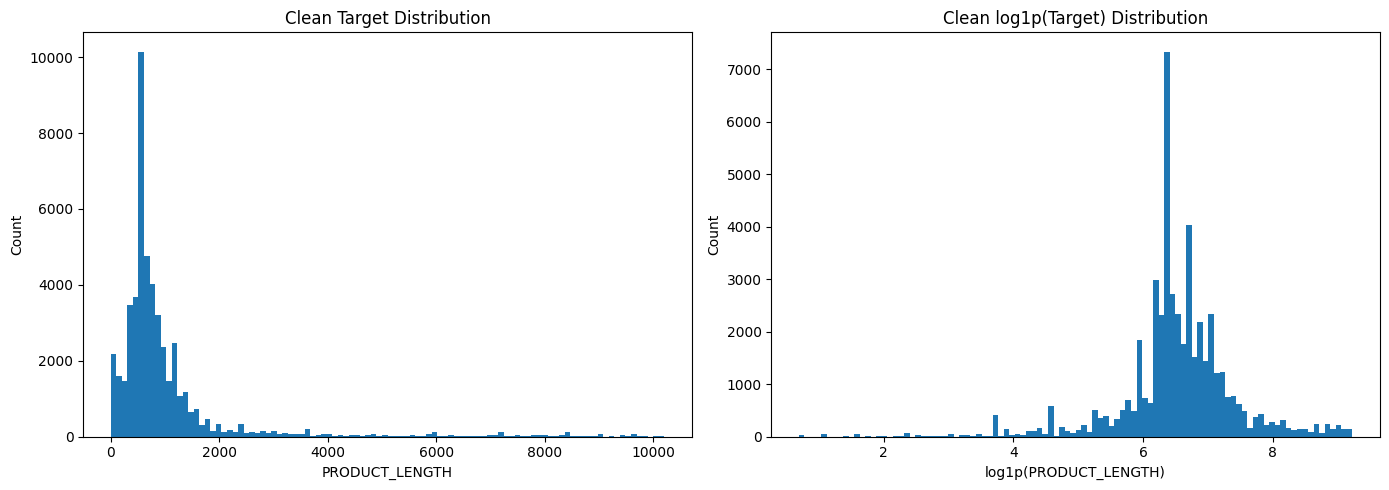

In [27]:

y_clean = train_clean["PRODUCT_LENGTH"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_clean, bins=100)
axes[0].set_title("Clean Target Distribution")
axes[0].set_xlabel("PRODUCT_LENGTH")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(y_clean), bins=100)
axes[1].set_title("Clean log1p(Target) Distribution")
axes[1].set_xlabel("log1p(PRODUCT_LENGTH)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 24. Save cleaning rules

In [28]:

rules = {
    "data_mode": DATA_MODE,
    "target_column": "PRODUCT_LENGTH",
    "target_outlier_method": "log1p_Q3_plus_3_IQR",
    "target_iqr_multiplier": TARGET_IQR_MULTIPLIER,
    "robust_target_upper_bound": robust_target_upper,
    "final_target_upper_bound": final_target_upper,
    "absolute_target_max": ABSOLUTE_TARGET_MAX,
    "remove_extreme_target_outliers": REMOVE_EXTREME_TARGET_OUTLIERS,
    "dimension_unit": "cm",
    "max_dimension_cm": MAX_DIMENSION_CM,
    "dimension_imputation": {
        "priority": [
            "PRODUCT_TYPE_ID median",
            "global training median",
            "1.0 fallback"
        ],
        "global_medians": global_dim_medians
    },
    "text_normalization": [
        "replace NaN with empty string",
        "remove zero-width characters",
        "replace newlines with spaces",
        "collapse repeated whitespace",
        "strip leading/trailing whitespace"
    ],
    "duplicate_policy": {
        "exact_rows": "keep_first",
        "PRODUCT_ID": "keep_first"
    }
}

with open(RULES_FILE, "w", encoding="utf-8") as f:
    json.dump(rules, f, indent=2, default=float)

print("Saved:", RULES_FILE)


Saved: ../dataset/cleaned\cleaning_rules_debug.json


## 25. Save cleaned datasets

In [29]:

train_clean.to_csv(CLEAN_TRAIN_FILE, index=False)
test.to_csv(CLEAN_TEST_FILE, index=False)

# Save the full audit for the original train dataframe.
audit_out = audit.copy()
audit_out["original_row_index"] = audit_out.index
audit_out.to_csv(AUDIT_FILE, index=False)

print("Saved files:")
print("Train:", CLEAN_TRAIN_FILE)
print("Test :", CLEAN_TEST_FILE)
print("Audit:", AUDIT_FILE)
print("Rules:", RULES_FILE)


Saved files:
Train: ../dataset/cleaned\train_clean_debug.csv
Test : ../dataset/cleaned\test_clean_debug.csv
Audit: ../dataset/cleaned\cleaning_audit_debug.csv
Rules: ../dataset/cleaned\cleaning_rules_debug.json



# Final Notebook 02 Output

The next notebook should **not reload the raw dataset**.

Use:

```text
dataset/cleaned/train_clean_<mode>.csv
dataset/cleaned/test_clean_<mode>.csv
```

### Notebook 03 should focus on feature engineering

Recommended order:

```text
Clean data
   ↓
Dimension features
   ↓
Numeric transformations
   ↓
Categorical handling
   ↓
TF-IDF / NLP
   ↓
Feature matrix
   ↓
Train/validation split
   ↓
Models
```

### Critical modeling rule

Do **not** fit target-derived statistics, TF-IDF vocabulary, scalers, encoders, or other learned transformations on validation/test data.

Fit them on the training split only.

This notebook is the **data-quality boundary**. Notebook 03/04 can therefore concentrate on feature engineering and NLP without repeatedly fixing raw-data problems.
